In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.metrics import classification_report
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, "../../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve, plot_trend_curve, plot_feature_importance

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
Q = 'Q1'
q = Q.lower()

file1 = f'../../../data/CMacedonia/{NUTS0}_CMacedonia_WNV_Dataset_{Q}_2010_2023.csv'
file2 = f'../../../data/Attica/{NUTS0}_Attica_WNV_Dataset_{Q}_2010_2023.csv'
file3 = f'../../../data/Thessaly/{NUTS0}_Thessaly_WNV_Dataset_{Q}_2010_2023.csv'
file4 = f'../../../data/Thrace/{NUTS0}_Thrace_WNV_Dataset_{Q}_2010_2023.csv'


dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)

dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])
dataset.reset_index(drop=True, inplace=True)

print(dataset.shape)

(308, 72)


In [2]:
dataset.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,6.145260,9.853286,16.614061,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.299580,-0.145977,0.137769,-0.137769,0.299260,-0.145249,0.138721,-0.138721,0.042502,0.043421,0.045998,0.045998,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.63,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,7.033430,10.522830,13.678385,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.246127,0.027913,0.235072,-0.235072,0.241160,0.029131,0.232349,-0.232349,0.048505,0.077228,0.061491,0.061491,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.33,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,6.595166,10.528780,11.666570,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.196208,0.181480,0.357342,-0.357342,0.198035,0.166190,0.342679,-0.342679,0.031112,0.058279,0.034329,0.034329,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.86,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,5.968107,9.954364,15.621303,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.334891,-0.232117,0.091553,-0.091553,0.328280,-0.228668,0.090159,-0.090159,0.047250,0.067269,0.062925,0.062925,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.78,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,7.550798,10.821806,15.959433,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.350204,-0.261349,0.082357,-0.082357,0.333338,-0.202925,0.110173,-0.110173,0.041642,0.051140,0.044747,0.044747,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.79,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13


In [3]:
len(dataset.NUTS3_ID.unique())

22

In [4]:
dataset.WNV_cases.sum()

1724

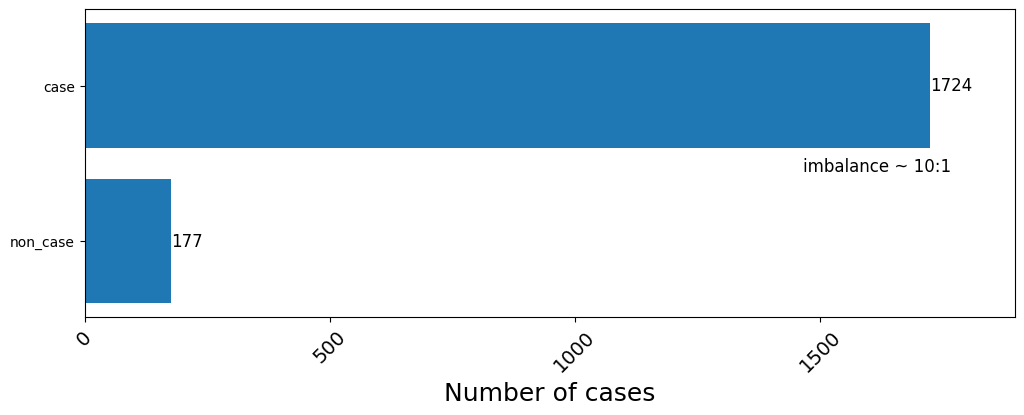

In [5]:
plot_imbalance(dataset, target_column='WNV_cases')

In [11]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,13,260,273,0.05%
1,2011,7,91,98,0.08%
2,2012,10,141,151,0.07%
3,2013,12,83,95,0.14%
4,2014,19,13,32,1.46%
5,2015,22,0,22,inf%
6,2016,22,0,22,inf%
7,2017,22,0,22,inf%
8,2018,4,293,297,0.01%
9,2019,5,221,226,0.02%


In [12]:
X = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']

In [13]:
n_folds = 5
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [14]:
features_to_remove = ['x', 'y', 'year']
features_to_remove = features_to_remove + ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1',
                                           'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw',
                                           'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 
                                           'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m',]
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

['min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1', 'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1', 'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15', 'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens']


In [15]:
print(f"Total Features Used: {len(feature_names)}")

Total Features Used: 47


In [53]:
majority_class = 1
near_u = 0
smote = 0.2
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []
  
for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='WNV_cases')
    # data_train['WNV_cases'] = data_train['WNV_cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['WNV_cases'] = data_test['WNV_cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    sum_negatives = data_train['WNV_cases'].value_counts().get(0)
    sum_positives = data_train['WNV_cases'].value_counts().get(1)

    if (smote != 0):
        if majority_class == 0:
            sum_positives = math.ceil(sum_positives * (1 + smote))
        elif majority_class == 1:
            sum_negatives = math.ceil(sum_negatives * (1 + smote))

    params = {
        "seed": 0,
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.1,           #default 0.3, range[0,1], decrease when model overfitts
        "min_split_loss": 0.3,          #default 0, range[0,inf], increase when model overfitts
        "max_depth": 3,                 #default 6, range[0,inf], decrease when model overfitts
        "reg_alpha": 0.5,               #default 0, range[0,inf], increase when model overfitts
        "reg_lambda": 1.5,              #default 1, range[0,inf], increase when model overfitts
        "min_child_weight": 1.5,        #default 1, range[0,inf], increase when model overfitts
        "scale_pos_weight": sum_negatives/sum_positives, 
    }

    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['WNV_cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['WNV_cases'])

    y_train = data_train['WNV_cases']
    y_test = data_test['WNV_cases']

    print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['WNV_cases'].value_counts().get(0) / data_test['WNV_cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")

    scaler = MinMaxScaler(feature_range = (-1, 1))
    #scaler = RobustScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    if (smote != 0):
        if majority_class == 0:
            sm = BorderlineSMOTE(sampling_strategy = {0: sum_negatives, 1: math.ceil(sum_positives * (1 + smote))}, n_jobs = -1, random_state = 0)
        elif majority_class == 1:
            sm = BorderlineSMOTE(sampling_strategy = {0: math.ceil(sum_negatives * (1 + smote)), 1: sum_positives}, n_jobs = -1, random_state = 0)

        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_imputed, y_train)

    X_train_final = X_train_imputed if (near_u == 0 and smote == 0) else X_train_resampled
    y_train_final = y_train if (near_u == 0 and smote == 0) else y_train_resampled

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_final, y_train_final)

    y_train_prob = trained_model.predict_proba(X_train_final)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train_final)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/5
Training set 0/1 Ratio: 0.13
Test set 0/1 Ratio: 1.38
Weight: 0.13
Fold: 2/5
Training set 0/1 Ratio: 0.13
Test set 0/1 Ratio: 1.38
Weight: 0.13
Fold: 3/5
Training set 0/1 Ratio: 0.12
Test set 0/1 Ratio: 1.30
Weight: 0.12
Fold: 4/5
Training set 0/1 Ratio: 0.12
Test set 0/1 Ratio: 1.35
Weight: 0.12
Fold: 5/5
Training set 0/1 Ratio: 0.13
Test set 0/1 Ratio: 1.35
Weight: 0.13


In [54]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [55]:
df_test = pd.DataFrame({'score': y_test_proba[:, 1], 'target': y_test_true})

In [56]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.1194
Test Loss: 0.4804


In [67]:
beta = 1

classification_thresholds = optimal_threashold_fbeta_scalar(y_test_proba[:,1], y_test_true, beta = beta, round_factor = 3)
print(classification_thresholds)

0.242


In [68]:
thr = classification_thresholds

In [69]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

In [70]:
print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.86      0.67      0.75       177
           1       0.65      0.85      0.74       131

    accuracy                           0.74       308
   macro avg       0.75      0.76      0.74       308
weighted avg       0.77      0.74      0.74       308



In [71]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[118  59]
 [ 20 111]]


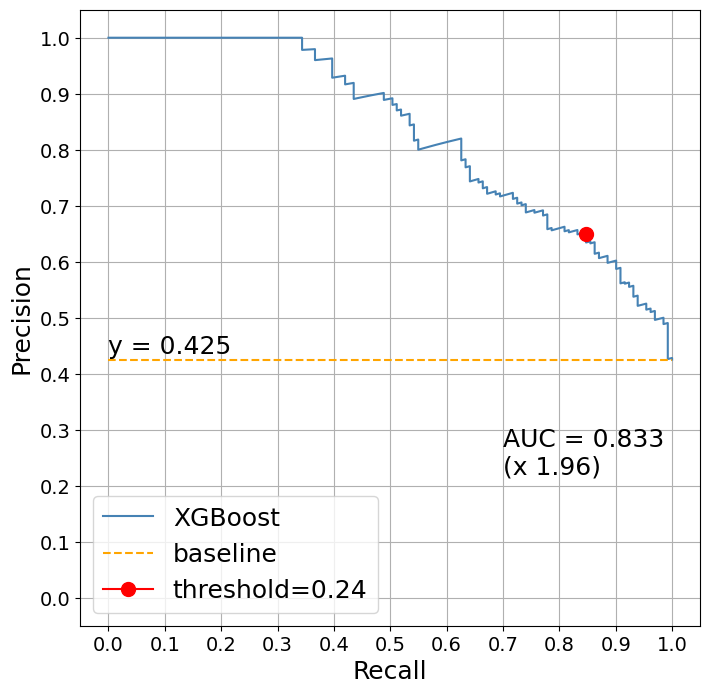

(0.8473, 0.65, 0.7375, 0.24)

In [157]:
plot_pr_curve(df_test, target_col = 'target', model_name='XGBoost', plot_fbeta=True, beta = beta)

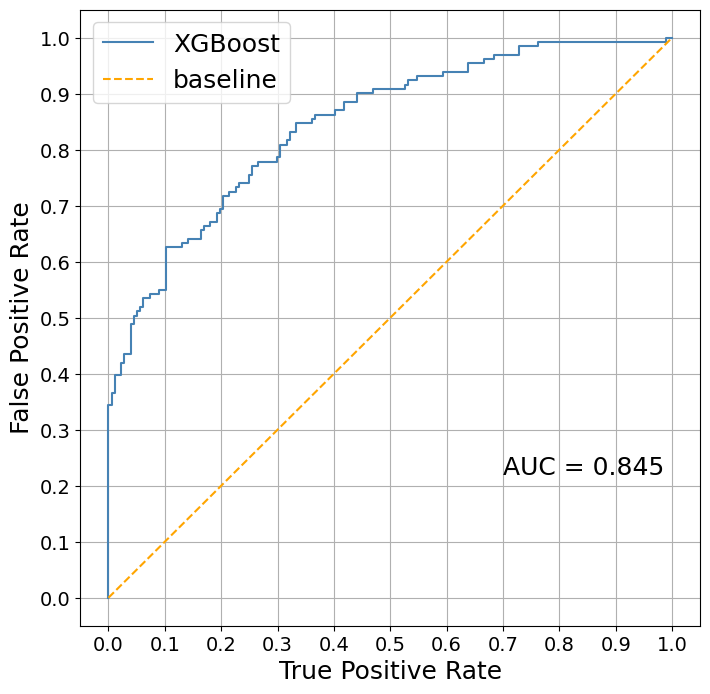

(0.2542, 0.771, 0.7583, 0.3109)

In [158]:
plot_roc_curve(df_test, target_col = 'target', model_name='XGBoost')

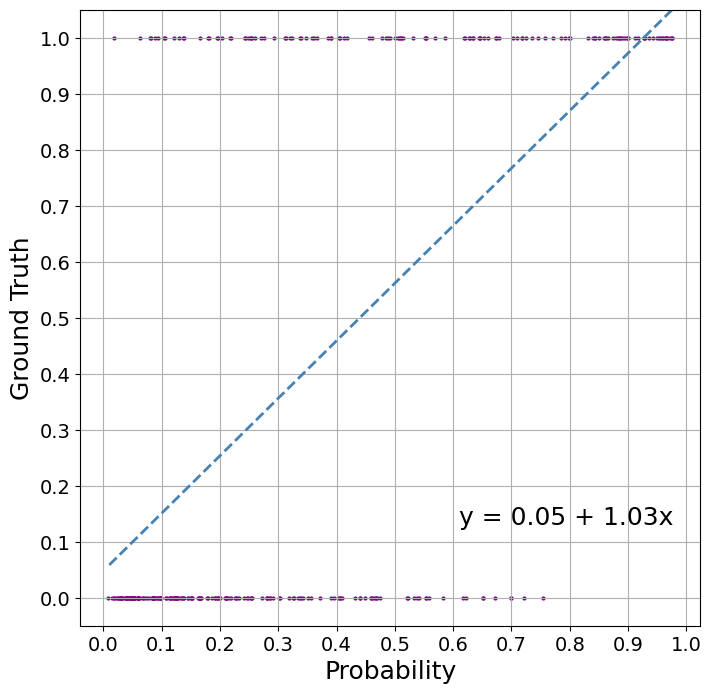

(0.04806378586590496, 1.0270270411848355)

In [159]:
plot_probability_curve(df_test, target_col = 'target', marker_size=4, marker_shape='o')

In [160]:
df_test['pred_01'] = df_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
df_test['pred_02'] = df_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
df_test['pred_05'] = df_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

df_test

,score,target,pred_01,pred_02,pred_05
0,0.975584,1,1,1,1
1,0.975134,1,1,1,1
2,0.971443,1,1,1,1
3,0.966689,1,1,1,1
4,0.966410,1,1,1,1
...,...,...,...,...,...
303,0.018628,0,0,0,0
304,0.018427,0,0,0,0
305,0.018248,1,0,0,0
306,0.015685,0,0,0,0


In [161]:
accuracy_01 = accuracy_score(df_test.target, df_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(df_test.target, df_test.pred_01)
fb_score_01 = fbeta_score(df_test.target, df_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(df_test.target, df_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(df_test.target, df_test.pred_01, labels = [0,1], zero_division = 0)
logloss_01 = log_loss(df_test.target, df_test.score, labels = [0,1])

accuracy_02 = accuracy_score(df_test.target, df_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(df_test.target, df_test.pred_02)
fb_score_02 = fbeta_score(df_test.target, df_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(df_test.target, df_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(df_test.target, df_test.pred_02, labels = [0,1], zero_division = 0)
logloss_02 = log_loss(df_test.target, df_test.score, labels = [0,1])

accuracy_05 = accuracy_score(df_test.target, df_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(df_test.target, df_test.pred_05)
fb_score_05 = fbeta_score(df_test.target, df_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(df_test.target, df_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(df_test.target, df_test.pred_05, labels = [0,1], zero_division = 0)
logloss_05 = log_loss(df_test.target, df_test.score, labels = [0,1])

In [162]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01, 'logloss': logloss_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02, 'logloss': logloss_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05, 'logloss': logloss_05}

results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

results_df

,accuracy,balanced_accuracy,f1_score,precision,recall,logloss
Threshold: 0.1,0.613636,0.657890,0.677507,0.525210,0.954198,0.480368
Threshold: 0.2,0.711039,0.731725,0.719243,0.612903,0.870229,0.480368
Threshold: 0.5,0.769481,0.746862,0.687225,0.812500,0.595420,0.480368


### SHAP Values ###

In [163]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['WNV_cases'] = data_train_shap['WNV_cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['WNV_cases'])
y_train = data_train_shap['WNV_cases']

sum_negatives = data_train_shap['WNV_cases'].value_counts().get(0)
sum_positives = data_train_shap['WNV_cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)

if (smote != 0):
    if majority_class == 0:
        sm = BorderlineSMOTE(sampling_strategy = {0: sum_negatives, 1: math.ceil(sum_positives * (1 + smote))}, n_jobs = -1, random_state = 0)
    elif majority_class == 1:
        sm = BorderlineSMOTE(sampling_strategy = {0: math.ceil(sum_negatives * (1 + smote)), 1: sum_positives}, n_jobs = -1, random_state = 0)

    X_train_resampled, y_train_resampled = sm.fit_resample(X_train_imputed, y_train)
    
X_train_final = X_train_imputed if (near_u == 0 and smote == 0) else X_train_resampled
y_train_final = y_train if (near_u == 0 and smote == 0) else y_train_resampled

X_train_final = pd.DataFrame(X_train_final, columns=X_train.columns)

In [164]:
params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_final, y_train_final)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_final)

In [165]:
location_columns = data_train_shap.iloc[:, :7]
wnv_columns = data_train_shap['WNV_cases']

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)
tree_shap_values_df['WNV_cases'] = tree_shap_values_df['WNV_cases'].fillna(0)

tree_shap_values_df

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2010.0,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,0.363237,0.191968,0.021826,-0.098694,0.015661,0.077012,0.315215,0.067753,-0.000064,0.385946,0.096811,0.073888,0.0,0.024523,0.001464,-0.071025,-0.048472,0.669937,0.046739,0.060101,-0.094133,0.199712,0.113985,0.0,-0.133081,0.073647,0.0,-0.006946,0.051523,-0.004454,0.0,0.103030,0.064817,-0.070111,0.0,-0.060924,0.023935,-0.024695,-0.007992,-0.001903,-0.002238,-0.002452,-0.000127,0.085408,0.021796,0.0,-0.193053,1.0
1,2010.0,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,0.267561,0.178172,0.016898,0.078475,0.035479,0.009937,0.093515,0.058299,0.019015,-0.083503,0.052554,0.075954,0.0,-0.007103,-0.001478,-0.086063,-0.125794,0.642778,0.062173,0.060101,-0.050326,0.422025,0.164566,0.0,0.451193,-0.033001,0.0,-0.006946,0.108397,-0.000170,0.0,0.132437,-0.168120,0.103434,0.0,0.246890,0.006184,0.226305,0.004954,-0.001903,0.001171,-0.002452,0.028249,0.040669,-0.031096,0.0,-0.213726,1.0
2,2010.0,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,0.353904,0.188246,0.021826,0.032892,0.042436,-0.101484,0.037235,0.061694,0.033092,0.194953,-0.157800,0.075954,0.0,-0.008820,-0.001478,0.122061,-0.047114,0.760433,0.051023,0.072815,-0.027083,0.504970,0.107687,0.0,0.415830,-0.030196,0.0,-0.006946,0.108397,-0.000716,0.0,0.202533,0.059144,0.014535,0.0,-0.102317,-0.048577,-0.040005,-0.010449,0.012500,-0.002238,0.015753,0.053854,-0.045725,-0.031096,0.0,0.030254,1.0
3,2010.0,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,0.350622,0.159029,0.021401,-0.098259,0.035479,0.068239,0.213814,0.067038,-0.000064,0.413301,0.096811,0.075954,0.0,0.024523,0.001464,-0.100782,-0.036185,0.742417,-0.163046,0.067710,-0.142378,0.491616,0.091316,0.0,-0.082073,-0.005802,0.0,-0.014129,-0.050852,0.028625,0.0,0.155492,-0.117071,0.070328,0.0,-0.046273,0.023935,0.030100,-0.007992,-0.001903,-0.002238,-0.002452,-0.000127,0.083298,0.021796,0.0,-0.212308,1.0
4,2010.0,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,0.229383,0.207348,0.016473,-0.068798,0.015661,0.070260,0.252613,0.065555,-0.005741,-0.088930,0.048683,0.075954,0.0,-0.008820,-0.001478,-0.094428,-0.074022,0.802254,0.062173,0.067710,-0.014722,0.059410,0.135376,0.0,-0.085658,-0.010994,0.0,-0.014129,-0.050852,0.004189,0.0,0.091385,0.064817,-0.090025,0.0,-0.069676,0.005323,-0.026073,-0.012340,-0.001903,-0.002238,-0.002452,-0.000127,0.088351,0.021796,0.0,-0.229382,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.570768,-0.245519,-0.001954,-0.449039,-0.002426,0.087161,-0.192216,0.019097,-0.033596,-0.092194,-0.004417,-0.094685,0.0,-0.052976,-0.001478,0.496626,-0.039979,-0.248258,0.051512,-0.038873,-0.058683,-0.071176,-0.497219,0.0,-0.002438,0.071611,0.0,0.018382,-0.017321,0.025873,0.0,0.074126,0.039391,-0.037564,0.0,0.183946,0.008258,-0.138343,0.004849,-0.001903,0.002539,-0.011796,0.000346,0.029432,0.008258,0.0,0.232679,0.0
340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032793,-0.046806,0.002872,-0.275911,0.015661,0.100234,-0.248647,0.006676,0.026858,-0.071004,-0.001061,0.073888,0.0,-0.052976,0.001464,0.333093,-0.032179,-0.228480,-0.078006,0.129713,0.368722,-0.927391,-0.205041,0.0,-0.105131,-0.019620,0.0,-0.044473,-0.057713,-0.053815,0.0,0.053842,0.021636,-0.094027,0.0,-0.058820,0.009119,0.001176,-0.030748,-0.010627,-0.004852,-0.011796,-0.001675,-0.019956,0.008258,0.0,-0.243940,0.0
341,NaN,Na

In [166]:
sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, 7:-1].abs().mean().sort_values(ascending=False).index

In [167]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
climate = [f'min_temp_{q}', f'mean_temp_{q}', f'max_temp_{q}', f'prec_{q}']
enviromental = [f'ndvi_{q}',f'ndwi_{q}',f'ndmi_{q}',f'ndbi_{q}',f'ndvi_mean_{q}',f'ndwi_mean_{q}',f'ndmi_mean_{q}',f'ndbi_mean_{q}',f'ndvi_std_{q}',f'ndwi_std_{q}',f'ndmi_std_{q}',f'ndbi_std_{q}']
demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']
vectors = ['culex_pipiens']
trade = ['L_TOTAL',	'UNL_TOTAL']
economic = ['MIO_EUR']

In [168]:
len(bioclimatic+climate+enviromental+demographic+vectors+trade+economic)

47

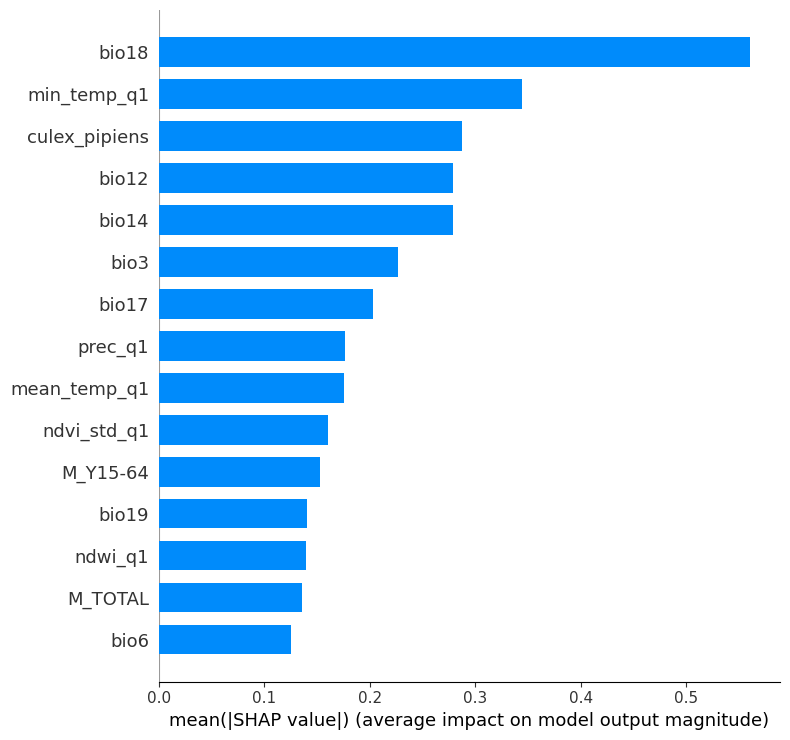

In [169]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='bar', max_display=15)

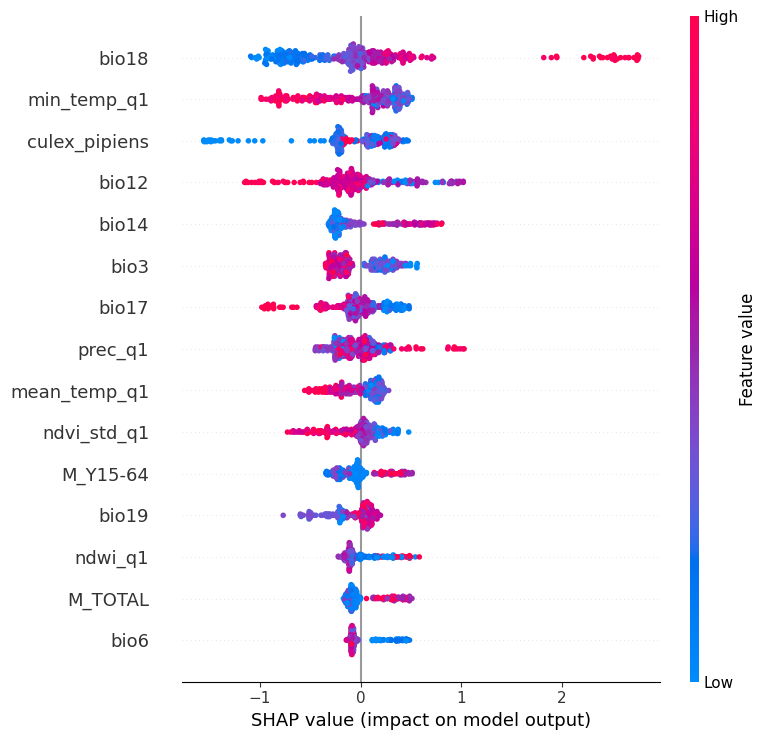

In [170]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=15)

In [171]:
tree_shap_values_df

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2010.0,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,0.363237,0.191968,0.021826,-0.098694,0.015661,0.077012,0.315215,0.067753,-0.000064,0.385946,0.096811,0.073888,0.0,0.024523,0.001464,-0.071025,-0.048472,0.669937,0.046739,0.060101,-0.094133,0.199712,0.113985,0.0,-0.133081,0.073647,0.0,-0.006946,0.051523,-0.004454,0.0,0.103030,0.064817,-0.070111,0.0,-0.060924,0.023935,-0.024695,-0.007992,-0.001903,-0.002238,-0.002452,-0.000127,0.085408,0.021796,0.0,-0.193053,1.0
1,2010.0,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,0.267561,0.178172,0.016898,0.078475,0.035479,0.009937,0.093515,0.058299,0.019015,-0.083503,0.052554,0.075954,0.0,-0.007103,-0.001478,-0.086063,-0.125794,0.642778,0.062173,0.060101,-0.050326,0.422025,0.164566,0.0,0.451193,-0.033001,0.0,-0.006946,0.108397,-0.000170,0.0,0.132437,-0.168120,0.103434,0.0,0.246890,0.006184,0.226305,0.004954,-0.001903,0.001171,-0.002452,0.028249,0.040669,-0.031096,0.0,-0.213726,1.0
2,2010.0,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,0.353904,0.188246,0.021826,0.032892,0.042436,-0.101484,0.037235,0.061694,0.033092,0.194953,-0.157800,0.075954,0.0,-0.008820,-0.001478,0.122061,-0.047114,0.760433,0.051023,0.072815,-0.027083,0.504970,0.107687,0.0,0.415830,-0.030196,0.0,-0.006946,0.108397,-0.000716,0.0,0.202533,0.059144,0.014535,0.0,-0.102317,-0.048577,-0.040005,-0.010449,0.012500,-0.002238,0.015753,0.053854,-0.045725,-0.031096,0.0,0.030254,1.0
3,2010.0,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,0.350622,0.159029,0.021401,-0.098259,0.035479,0.068239,0.213814,0.067038,-0.000064,0.413301,0.096811,0.075954,0.0,0.024523,0.001464,-0.100782,-0.036185,0.742417,-0.163046,0.067710,-0.142378,0.491616,0.091316,0.0,-0.082073,-0.005802,0.0,-0.014129,-0.050852,0.028625,0.0,0.155492,-0.117071,0.070328,0.0,-0.046273,0.023935,0.030100,-0.007992,-0.001903,-0.002238,-0.002452,-0.000127,0.083298,0.021796,0.0,-0.212308,1.0
4,2010.0,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,0.229383,0.207348,0.016473,-0.068798,0.015661,0.070260,0.252613,0.065555,-0.005741,-0.088930,0.048683,0.075954,0.0,-0.008820,-0.001478,-0.094428,-0.074022,0.802254,0.062173,0.067710,-0.014722,0.059410,0.135376,0.0,-0.085658,-0.010994,0.0,-0.014129,-0.050852,0.004189,0.0,0.091385,0.064817,-0.090025,0.0,-0.069676,0.005323,-0.026073,-0.012340,-0.001903,-0.002238,-0.002452,-0.000127,0.088351,0.021796,0.0,-0.229382,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.570768,-0.245519,-0.001954,-0.449039,-0.002426,0.087161,-0.192216,0.019097,-0.033596,-0.092194,-0.004417,-0.094685,0.0,-0.052976,-0.001478,0.496626,-0.039979,-0.248258,0.051512,-0.038873,-0.058683,-0.071176,-0.497219,0.0,-0.002438,0.071611,0.0,0.018382,-0.017321,0.025873,0.0,0.074126,0.039391,-0.037564,0.0,0.183946,0.008258,-0.138343,0.004849,-0.001903,0.002539,-0.011796,0.000346,0.029432,0.008258,0.0,0.232679,0.0
340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032793,-0.046806,0.002872,-0.275911,0.015661,0.100234,-0.248647,0.006676,0.026858,-0.071004,-0.001061,0.073888,0.0,-0.052976,0.001464,0.333093,-0.032179,-0.228480,-0.078006,0.129713,0.368722,-0.927391,-0.205041,0.0,-0.105131,-0.019620,0.0,-0.044473,-0.057713,-0.053815,0.0,0.053842,0.021636,-0.094027,0.0,-0.058820,0.009119,0.001176,-0.030748,-0.010627,-0.004852,-0.011796,-0.001675,-0.019956,0.008258,0.0,-0.243940,0.0
341,NaN,Na

,features,weights
0,bioclimatic,2.336444
1,climate,0.713253
2,enviromental,0.588128
3,demographic,0.360640
4,vectors,0.287066
6,economic,0.058038
5,trade,0.015075


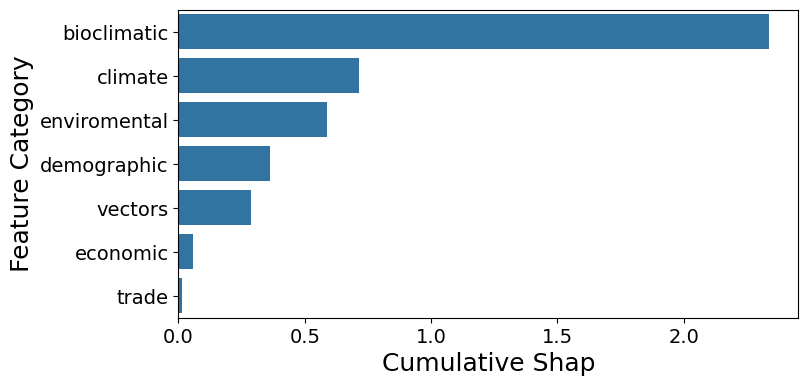

In [172]:
df_bioclimatic = tree_shap_values_df[bioclimatic].abs().mean(axis = 0)
df_climate = tree_shap_values_df[climate].abs().mean(axis = 0)
df_enviromental = tree_shap_values_df[enviromental].abs().mean(axis = 0)
df_demographic = tree_shap_values_df[demographic].abs().mean(axis = 0)
df_vectors = tree_shap_values_df[vectors].abs().mean(axis = 0)
df_trade = tree_shap_values_df[trade].abs().mean(axis = 0)
df_economic = tree_shap_values_df[economic].abs().mean(axis = 0)

categories_df = pd.DataFrame.from_dict({'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
                                        'Cumulative_Shap': [df_bioclimatic.sum(),df_climate.sum(),df_enviromental.sum(), df_demographic.sum(),df_vectors.sum(),df_trade.sum(),df_economic.sum()]})

categories_df.sort_values(by = 'Cumulative_Shap', ascending=False)

plot_feature_importance(categories_df.Cumulative_Shap.to_numpy().reshape(1,7), categories_df.Category, y_label='Feature Category', x_label = 'Cumulative Shap', figure_size = (8, 4))

,features,weights
4,vectors,0.287066
1,climate,0.178313
0,bioclimatic,0.122971
6,economic,0.058038
2,enviromental,0.049011
3,demographic,0.045080
5,trade,0.007538


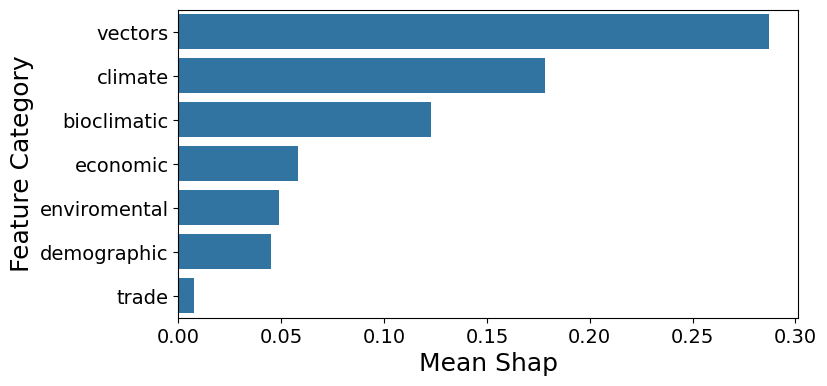

In [173]:
categories_df = pd.DataFrame.from_dict({'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
                                        'Mean_Shap': [df_bioclimatic.mean(),df_climate.mean(),df_enviromental.mean(), df_demographic.mean(),df_vectors.mean(),df_trade.mean(),df_economic.mean()]})

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

plot_feature_importance(categories_df.Mean_Shap.to_numpy().reshape(1,7), categories_df.Category, y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))